# Data Exploration

In [1]:
import pandas as pd
import openpyxl

data_adidas = pd.read_excel("../data/dataset.xlsx", sheet_name="adidas")
data_puma = pd.read_excel("../data/dataset.xlsx", sheet_name="puma")
data_asics = pd.read_excel("../data/dataset.xlsx", sheet_name="asics")
data_mizuno = pd.read_excel("../data/dataset.xlsx", sheet_name="mizuno")


# Exploratory Data Analysis (EDA)
To the data distribution, term frequencies, and identifying potential issues.

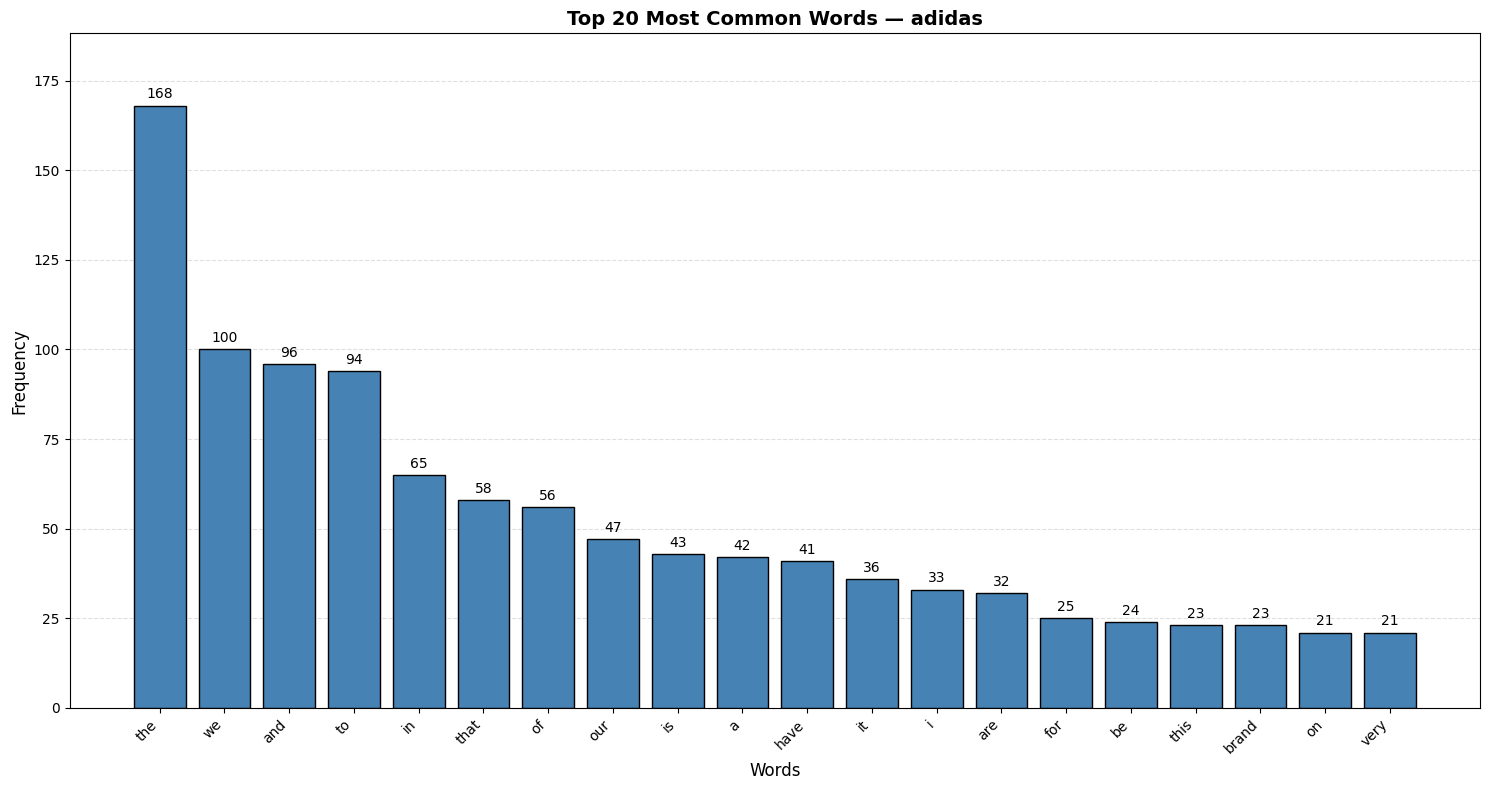

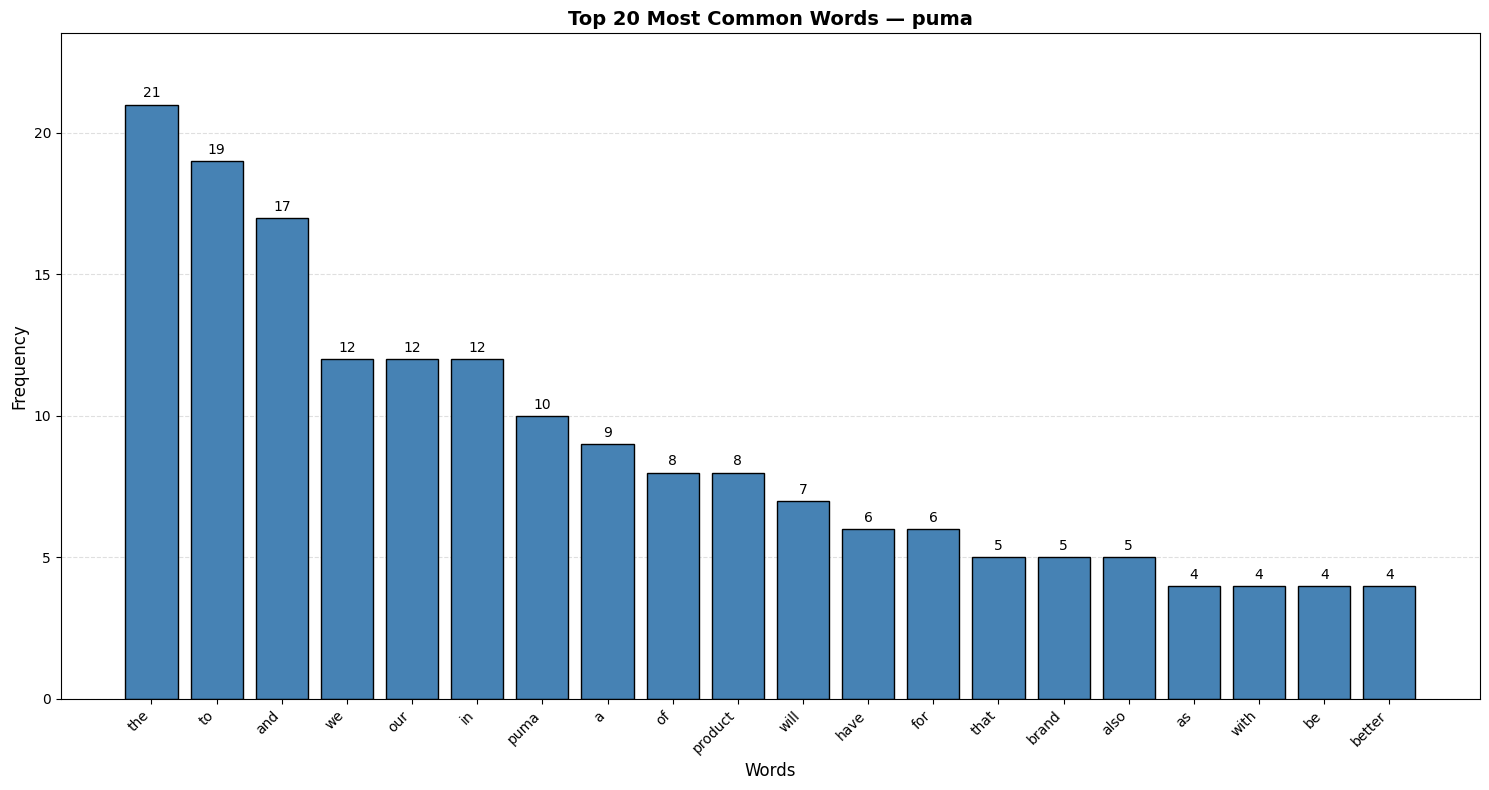

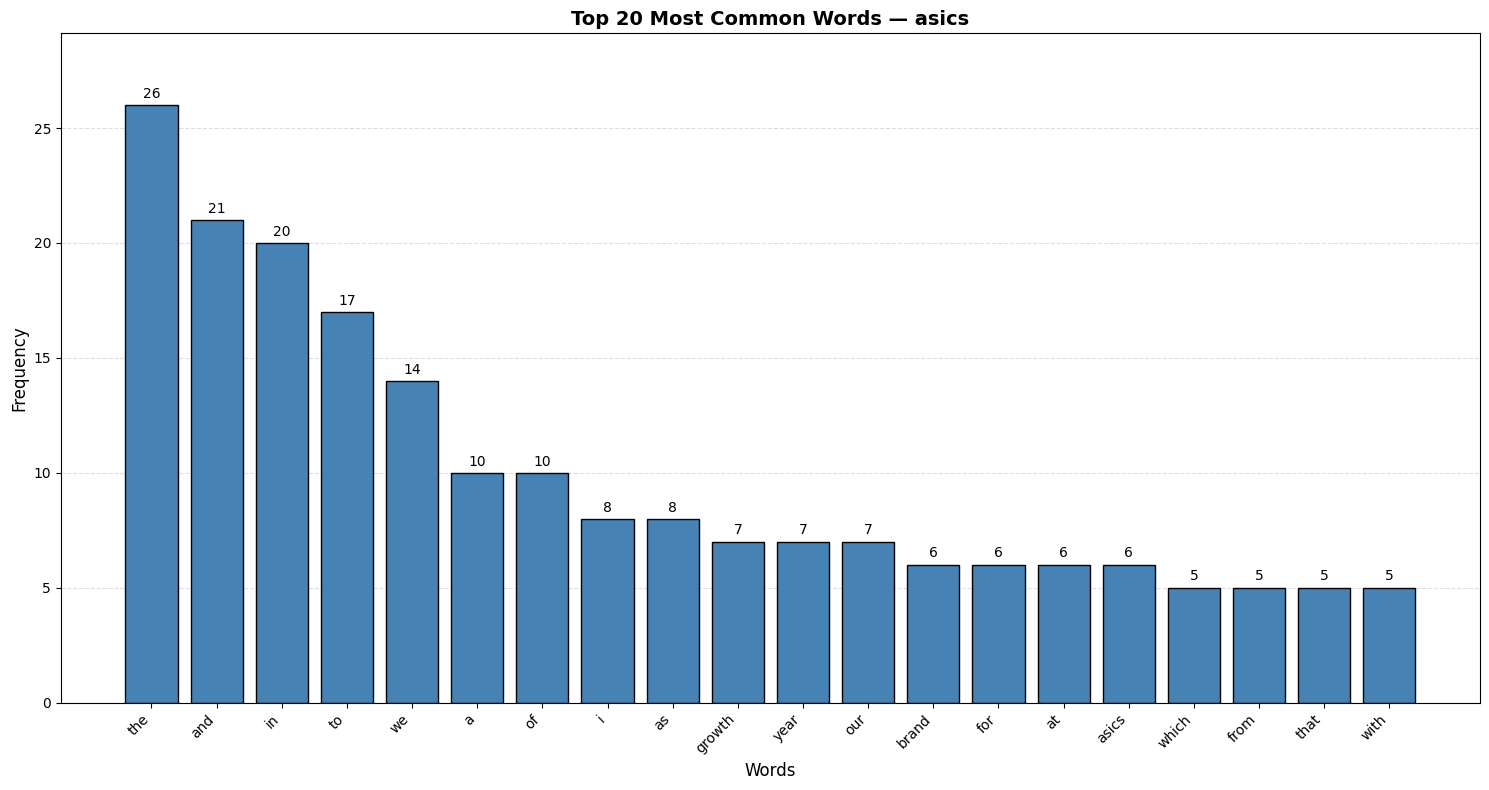

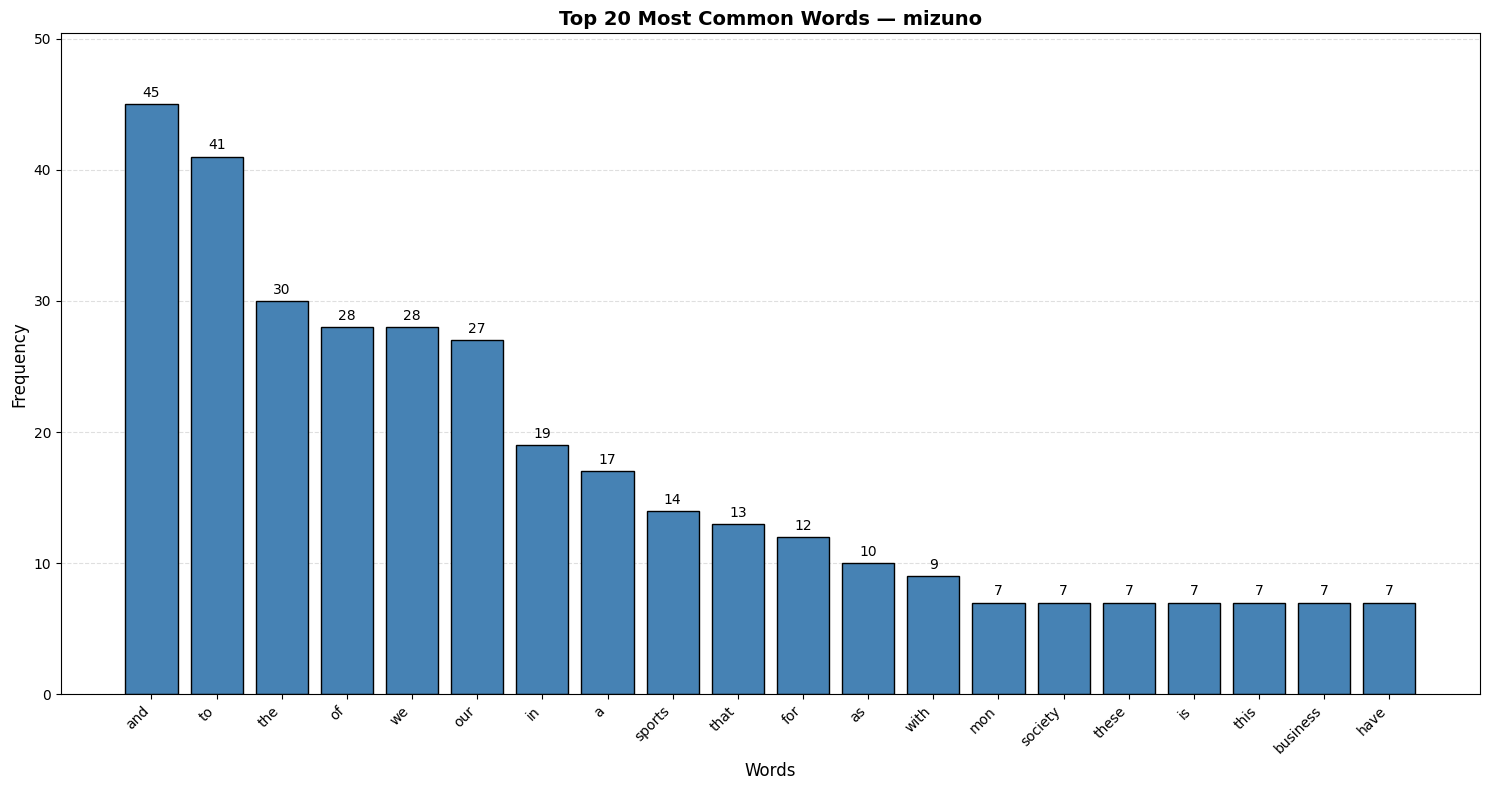

In [2]:
import re
import matplotlib.pyplot as plt
from collections import Counter

datasets = {
    "adidas": data_adidas,
    "puma": data_puma,
    "asics": data_asics,
    "mizuno": data_mizuno,
}

for company, data in datasets.items():
    # Work on a copy so the original dataset stays unchanged
    df = data.copy()

    # Exclude interviewer questions when analyzing CEO language
    if "Communication_type" in df.columns:
        question_rows = (
            df["Communication_type"]
            .astype("string")
            .str.strip()
            .str.lower()
            .isin(["interview_question", "question"])
        )
        df = df.loc[~question_rows]

    # Combine text, lowercase, and remove punctuation from word counts
    text = " ".join(df["Text"].dropna().astype(str))
    all_words = re.findall(r"\b[a-z]+(?:['’][a-z]+)*\b", text.lower())

    common_words = Counter(all_words).most_common(20)

    if not common_words:
        print(f"No words found for {company}.")
        continue

    words, counts = zip(*common_words)

    fig, ax = plt.subplots(figsize=(15, 8))
    bars = ax.bar(words, counts, color="steelblue", edgecolor="black")

    ax.set_title(
        f"Top 20 Most Common Words — {company}",
        fontsize=14,
        fontweight="bold",
    )
    ax.set_xlabel("Words", fontsize=12)
    ax.set_ylabel("Frequency", fontsize=12)

    ax.bar_label(bars, padding=3, fontsize=10)
    ax.margins(y=0.12)
    ax.tick_params(axis="x", rotation=45)
    plt.setp(ax.get_xticklabels(), ha="right")

    ax.set_axisbelow(True)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

    fig.tight_layout()
    plt.show()
    plt.close(fig)

# Sentiment Analysis TEST with BERT

In [3]:
import numpy as np
import pandas as pd
import torch

from transformers import AutoTokenizer, AutoModelForSequenceClassification

MODEL_NAME = "ProsusAI/finbert"

# CPU works without a GPU
device = torch.device("cpu")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)
model.to(device)
model.eval()

# Read the label order from the model rather than assuming it
labels = [
    model.config.id2label[i].lower()
    for i in range(model.config.num_labels)
]

assert set(labels) == {"positive", "neutral", "negative"}

max_length = min(
    tokenizer.model_max_length,
    model.config.max_position_embeddings,
)

chunk_size = max_length - tokenizer.num_special_tokens_to_add(pair=False)

print("Model loaded:", MODEL_NAME)

/Users/Saowalak/miniforge3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Model loaded: ProsusAI/finbert


In [8]:
def score_paragraph(text):
    empty_result = {
        "Sentiment_status": "missing_text",
        "P_positive": np.nan,
        "P_neutral": np.nan,
        "P_negative": np.nan,
        "Sentiment_label": None,
        "Sentiment_score": np.nan,
        "Token_count": 0,
        "Chunk_count": 0,
    }

    if not isinstance(text, str) or not text.strip():
        return empty_result

    token_ids = tokenizer(
        text,
        add_special_tokens=False,
        truncation=False,
    )["input_ids"]

    if not token_ids:
        return empty_result

    chunks = [
        token_ids[i:i + chunk_size]
        for i in range(0, len(token_ids), chunk_size)
    ]

    chunk_probabilities = []

    for chunk in chunks:
        inputs = tokenizer.prepare_for_model(
            chunk,
            add_special_tokens=True,
            return_attention_mask=True,
            return_tensors="pt",
        )

        inputs = {
            key: (
                value.unsqueeze(0) if value.ndim == 1 else value
            ).to(device)
            for key, value in inputs.items()
            if key in tokenizer.model_input_names
        }       

        with torch.inference_mode():
            logits = model(**inputs).logits
            probabilities = torch.softmax(logits, dim=-1)

        chunk_probabilities.append(
            probabilities[0].cpu().numpy()
        )

    averaged_probabilities = np.average(
        chunk_probabilities,
        axis=0,
        weights=[len(chunk) for chunk in chunks],
    )

    probabilities_by_label = dict(
        zip(labels, averaged_probabilities)
    )

    return {
        "Sentiment_status": "scored",
        "P_positive": float(probabilities_by_label["positive"]),
        "P_neutral": float(probabilities_by_label["neutral"]),
        "P_negative": float(probabilities_by_label["negative"]),
        "Sentiment_label": labels[int(np.argmax(averaged_probabilities))],
        "Sentiment_score": float(
            probabilities_by_label["positive"]
            - probabilities_by_label["negative"]
        ),
        "Token_count": len(token_ids),
        "Chunk_count": len(chunks),
    }

In [9]:
sentiment_datasets = {}

for company, data in datasets.items():
    print(f"Processing {company}: {len(data)} rows...")

    df = data.copy().reset_index(drop=True)

    required = {"ID", "Text", "Communication_type"}
    missing = required - set(df.columns)

    if missing:
        raise ValueError(f"{company}: missing columns {missing}")

    if df["ID"].isna().any() or df["ID"].duplicated().any():
        raise ValueError(f"{company}: missing or duplicate IDs")

    # Score each paragraph without changing Text or manual coding
    scores = pd.DataFrame(
        [score_paragraph(text) for text in df["Text"]],
        columns=[
            "Sentiment_status",
            "P_positive",
            "P_neutral",
            "P_negative",
            "Sentiment_label",
            "Sentiment_score",
            "Token_count",
            "Chunk_count",
        ],
    )
    

    # Allows this cell to be rerun without duplicating output columns
    df = df.drop(columns=scores.columns, errors="ignore")
    df = pd.concat([df, scores], axis=1)

    communication_type = (
        df["Communication_type"]
        .astype("string")
        .str.strip()
        .str.lower()
    )

    df["CEO_analysis"] = (
        communication_type.isin(
            ["Interview_answer", "Interview_question", "Interview_quote", "Message", "Message_quote",  "Letter", "Letter-quote"]
        )
        & df["Sentiment_status"].eq("scored")
    )

    sentiment_datasets[company] = df

    print(f"Finished {company}")

data_adidas_sentiment = sentiment_datasets["adidas"]
data_puma_sentiment = sentiment_datasets["puma"]
data_asics_sentiment = sentiment_datasets["asics"]
data_mizuno_sentiment = sentiment_datasets["mizuno"]

Processing adidas: 37 rows...
Finished adidas
Processing puma: 8 rows...
Finished puma
Processing asics: 9 rows...
Finished asics
Processing mizuno: 14 rows...
Finished mizuno


In [13]:
from pathlib import Path
import pandas as pd

output_folder = Path("../data/sentiment_results")
output_folder.mkdir(parents=True, exist_ok=True)

# Save one CSV per company
for company, df in sentiment_datasets.items():
    file_path = output_folder / f"{company}_sentiment.csv"
    df.to_csv(file_path, index=False, encoding="utf-8-sig")
    print(f"Saved {len(df)} rows: {file_path.resolve()}")

# Combine all companies and save another CSV
all_sentiment = pd.concat(
    sentiment_datasets.values(),
    ignore_index=True,
)

file_path = output_folder / "all_companies_sentiment.csv"
all_sentiment.to_csv(file_path, index=False, encoding="utf-8-sig")

print(f"Saved {len(all_sentiment)} rows: {file_path.resolve()}")

Saved 37 rows: /Users/Saowalak/Desktop/CEOContext/data/sentiment_results/adidas_sentiment.csv
Saved 8 rows: /Users/Saowalak/Desktop/CEOContext/data/sentiment_results/puma_sentiment.csv
Saved 9 rows: /Users/Saowalak/Desktop/CEOContext/data/sentiment_results/asics_sentiment.csv
Saved 14 rows: /Users/Saowalak/Desktop/CEOContext/data/sentiment_results/mizuno_sentiment.csv
Saved 68 rows: /Users/Saowalak/Desktop/CEOContext/data/sentiment_results/all_companies_sentiment.csv


In [16]:
all_sentiment.head()


,ID,Company,Country,Year,Covid,CEO,Communication_type,Leadership_context,Information_valence,Comment,Text,Sentiment_status,P_positive,P_neutral,P_negative,Sentiment_label,Sentiment_score,Token_count,Chunk_count,CEO_analysis
0,DEU25A100,adidas,DEU,2025,False,Bjørn Gulden,Interview_quote,MARKET,Neutral/Mixed,Opening pull quote about the brand’s global po...,The global potential for adidas is almost unli...,scored,0.457926,0.532778,0.009296,neutral,0.448630,9,1,False
1,DEU25A201,adidas,DEU,2025,False,Bjørn Gulden,Interview_question,MARKET,NaN,"Asks about a memorable sports event, centering...","Bjørn, 2025 was quite an eventful year, to say...",scored,0.088470,0.891882,0.019649,neutral,0.068821,37,1,False
2,DEU25A202,adidas,DEU,2025,False,Bjørn Gulden,Interview_quote,MARKET,Neutral/Mixed,"Brand presence through athletes, products and ...",Given the huge amount of great sports events o...,scored,0.281339,0.697829,0.020832,neutral,0.260508,86,1,False
3,DEU25A301,adidas,DEU,2025,False,Bjørn Gulden,Interview_question,PERF,NaN,Requests a retrospective assessment of busines...,"Turning to the business, how would you summari...",scored,0.029613,0.941053,0.029334,neutral,0.000279,14,1,False
4,DEU25A302,adidas,DEU,2025,False,Bjørn Gulden,Interview_quote,PERF,Positive,"Reviews achieved goals, faster-than-expected p...",I am very happy and proud of what our people h...,scored,0.777535,0.211314,0.011151,positive,0.766384,231,1,False


# Analysis after the Sentiment Analysis

In [17]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

input_file = Path("../data/sentiment_results/all_companies_sentiment.csv")
output_folder = Path("../data/sentiment_results/graphs")
output_folder.mkdir(parents=True, exist_ok=True)

data = pd.read_csv(input_file)

required = {
    "ID", "Company", "Country", "Year", "Communication_type",
    "Leadership_context", "Information_valence",
    "Sentiment_label", "Sentiment_score",
    "P_positive", "P_neutral", "P_negative",
}

missing = required - set(data.columns)
if missing:
    raise ValueError(f"Missing columns: {sorted(missing)}")

ids = data["ID"].astype("string").str.strip()
if ids.isna().any() or ids.eq("").any() or ids.duplicated().any():
    raise ValueError("Review missing or duplicate IDs before analysis.")

# Normalize categories
data["Company"] = data["Company"].astype("string").str.strip().str.lower()
data["Country"] = data["Country"].astype("string").str.strip().str.upper()
data["Leadership_context"] = (
    data["Leadership_context"].astype("string").str.strip().str.upper()
)
data["Sentiment_label"] = (
    data["Sentiment_label"].astype("string").str.strip().str.lower()
)

valence = (
    data["Information_valence"]
    .astype("string")
    .str.strip()
    .str.lower()
    .str.replace(r"\s+", "", regex=True)
)

data["Valence_group"] = valence.map({
    "positive": "Positive",
    "neutral/mixed": "Neutral/Mixed",
    "negative": "Negative",
})

numeric_columns = [
    "Year", "Sentiment_score",
    "P_positive", "P_neutral", "P_negative",
]

for column in numeric_columns:
    data[column] = pd.to_numeric(data[column], errors="coerce")

probabilities = data[["P_positive", "P_neutral", "P_negative"]]

valid_scores = (
    probabilities.notna().all(axis=1)
    & probabilities.ge(0).all(axis=1)
    & probabilities.le(1).all(axis=1)
    & np.isclose(probabilities.sum(axis=1), 1, atol=1e-4)
    & data["Sentiment_score"].between(-1, 1)
    & np.isclose(
        data["Sentiment_score"],
        data["P_positive"] - data["P_negative"],
        atol=1e-4,
    )
    & data["Sentiment_label"].isin(["negative", "neutral", "positive"])
)

communication = (
    data["Communication_type"].astype("string").str.strip().str.lower()
)

# Rebuild the flag rather than relying on the saved True/False values
data["CEO_analysis"] = (
    communication.isin(
        ["interview_quote", "interview", "message", "letter"]
    )
    & valid_scores
)

ceo = data.loc[data["CEO_analysis"]].copy()

if ceo.empty:
    raise ValueError("No valid CEO observations found. Check types and scores.")

print(f"All rows: {len(data)}")
print(f"CEO observations included: {len(ceo)}")
print(f"Rows excluded: {len(data) - len(ceo)}")
print(f"CEO rows without recognized valence: {ceo['Valence_group'].isna().sum()}")

display(
    ceo.groupby("Company").agg(
        observations=("ID", "size"),
        years=("Year", "nunique"),
        mean_sentiment=("Sentiment_score", "mean"),
        median_sentiment=("Sentiment_score", "median"),
    ).round(3)
)

sns.set_theme(style="whitegrid")

sentiment_order = ["negative", "neutral", "positive"]
valence_order = ["Negative", "Neutral/Mixed", "Positive"]
context_order = ["PERF", "STRAT", "MARKET", "CHALL", "PEOPLE", "STAKE"]

def save_plot(fig, filename):
    fig.tight_layout()
    fig.savefig(
        output_folder / f"{filename}.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()
    plt.close(fig)

All rows: 68
CEO observations included: 50
Rows excluded: 18
CEO rows without recognized valence: 0


,observations,years,mean_sentiment,median_sentiment
Company,,,,
adidas,19,1,0.384,0.261
asics,9,1,0.820,0.921
mizuno,14,1,0.401,0.396
puma,8,1,0.553,0.773


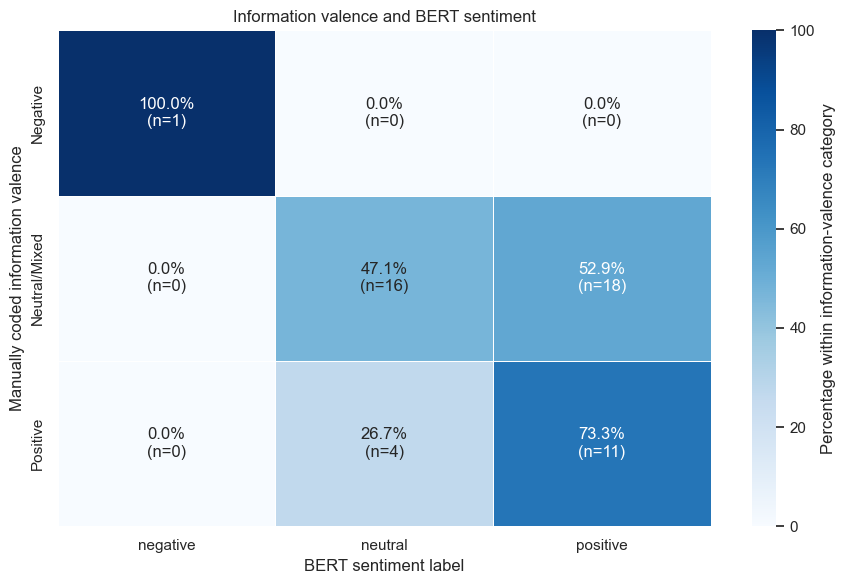

In [18]:
comparison = ceo.dropna(subset=["Valence_group"])

if comparison.empty:
    raise ValueError("No recognized Information_valence values to compare.")

counts = pd.crosstab(
    comparison["Valence_group"],
    comparison["Sentiment_label"],
).reindex(
    index=valence_order,
    columns=sentiment_order,
    fill_value=0,
)

percentages = (
    counts.div(counts.sum(axis=1).replace(0, np.nan), axis=0) * 100
)

annotations = pd.DataFrame(
    "",
    index=counts.index,
    columns=counts.columns,
)

for row in counts.index:
    for column in counts.columns:
        value = percentages.loc[row, column]
        if pd.notna(value):
            annotations.loc[row, column] = (
                f"{value:.1f}%\n(n={counts.loc[row, column]})"
            )

fig, ax = plt.subplots(figsize=(9, 6))

sns.heatmap(
    percentages,
    annot=annotations,
    fmt="",
    cmap="Blues",
    vmin=0,
    vmax=100,
    linewidths=0.5,
    cbar_kws={"label": "Percentage within information-valence category"},
    ax=ax,
)

ax.set_title("Information valence and BERT sentiment")
ax.set_xlabel("BERT sentiment label")
ax.set_ylabel("Manually coded information valence")

save_plot(fig, "01_valence_vs_sentiment")

counts.to_csv(output_folder / "valence_sentiment_counts.csv")
percentages.to_csv(output_folder / "valence_sentiment_percentages.csv")

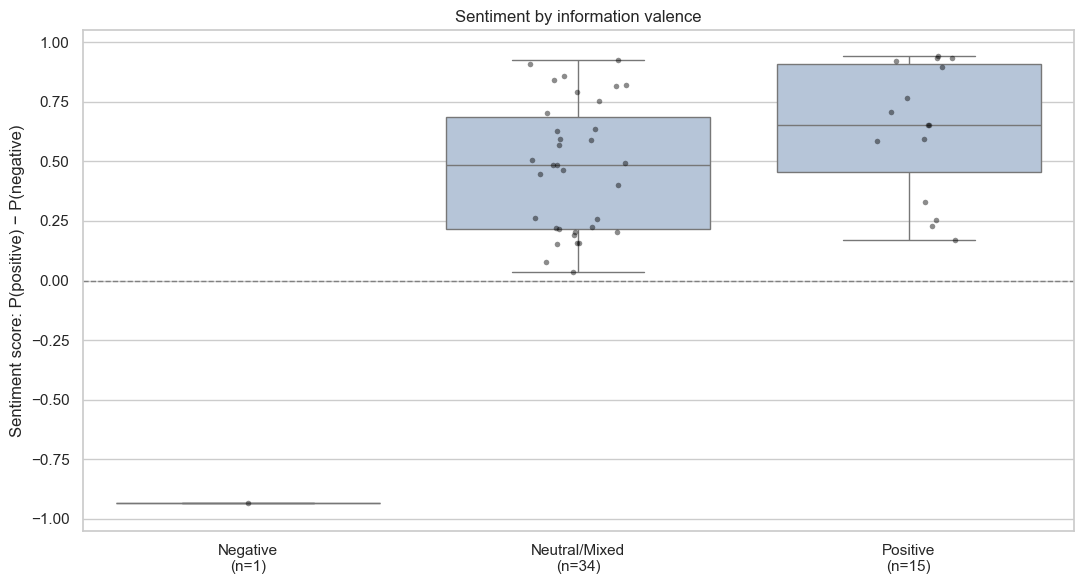

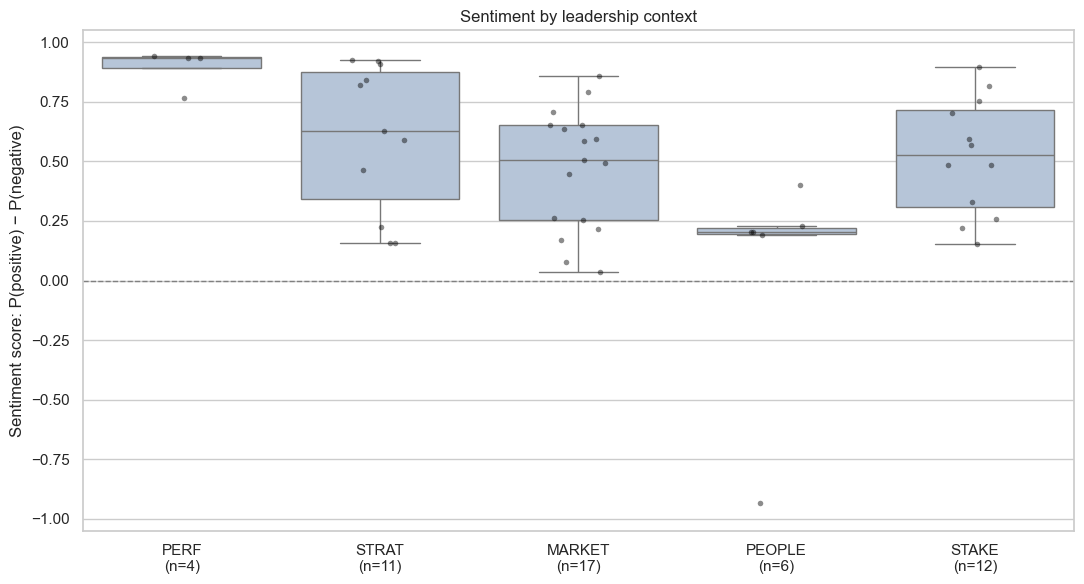

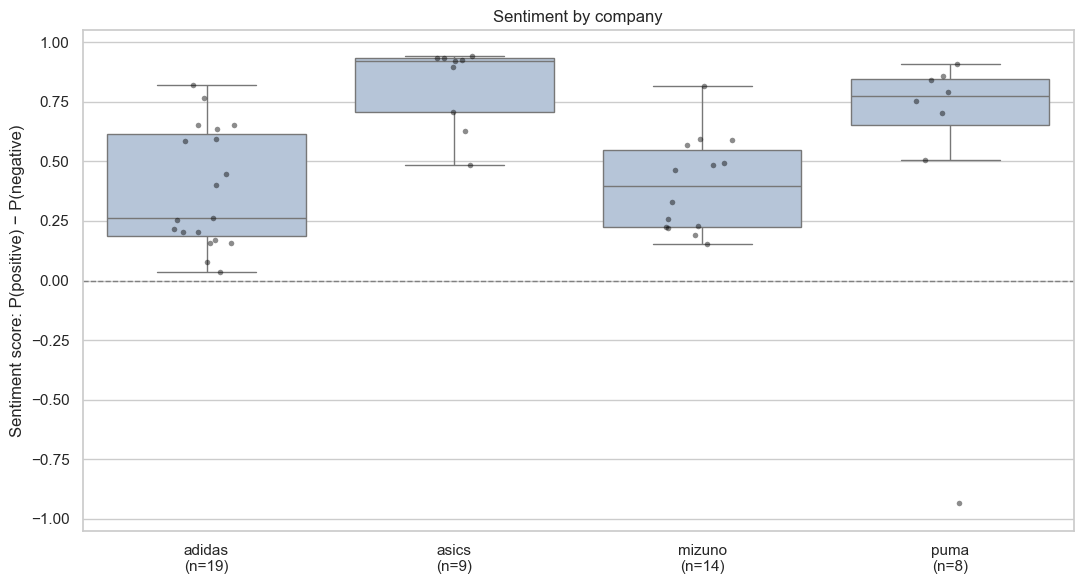

In [19]:
comparisons = [
    (
        "Valence_group",
        valence_order,
        "Sentiment by information valence",
        "02_sentiment_by_valence",
    ),
    (
        "Leadership_context",
        context_order,
        "Sentiment by leadership context",
        "03_sentiment_by_context",
    ),
    (
        "Company",
        sorted(ceo["Company"].dropna().unique()),
        "Sentiment by company",
        "04_sentiment_by_company",
    ),
]

for column, requested_order, title, filename in comparisons:
    plot_data = ceo.dropna(subset=[column])
    order = [
        value for value in requested_order
        if value in plot_data[column].unique()
    ]

    if not order:
        continue

    fig, ax = plt.subplots(figsize=(11, 6))

    sns.boxplot(
        data=plot_data,
        x=column,
        y="Sentiment_score",
        order=order,
        color="lightsteelblue",
        showfliers=False,
        ax=ax,
    )

    sns.stripplot(
        data=plot_data,
        x=column,
        y="Sentiment_score",
        order=order,
        color="black",
        alpha=0.45,
        jitter=0.15,
        size=4,
        ax=ax,
    )

    sample_sizes = plot_data[column].value_counts()
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels([
        f"{value}\n(n={sample_sizes[value]})"
        for value in order
    ])

    ax.axhline(0, color="gray", linestyle="--", linewidth=1)
    ax.set_ylim(-1.05, 1.05)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("Sentiment score: P(positive) − P(negative)")

    save_plot(fig, filename)

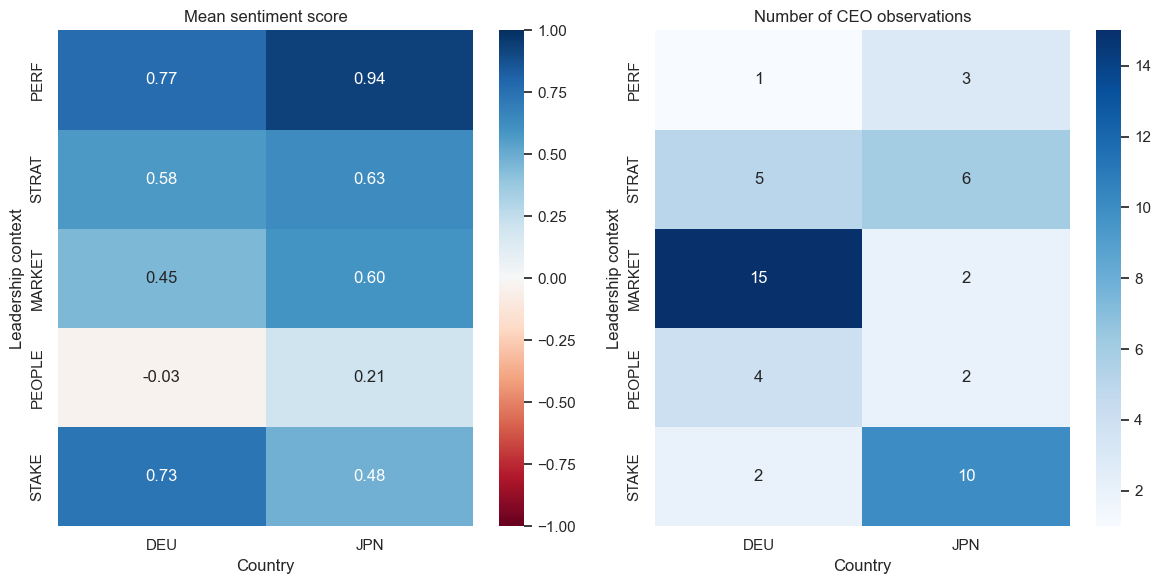

In [20]:
context_country = ceo.dropna(
    subset=["Leadership_context", "Country"]
)

means = context_country.pivot_table(
    index="Leadership_context",
    columns="Country",
    values="Sentiment_score",
    aggfunc="mean",
)

sample_sizes = pd.crosstab(
    context_country["Leadership_context"],
    context_country["Country"],
)

available_contexts = [
    context for context in context_order
    if context in means.index
]

means = means.reindex(available_contexts)
sample_sizes = sample_sizes.reindex(
    index=means.index,
    columns=means.columns,
    fill_value=0,
)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

sns.heatmap(
    means,
    annot=True,
    fmt=".2f",
    cmap="RdBu",
    center=0,
    vmin=-1,
    vmax=1,
    ax=axes[0],
)
axes[0].set_title("Mean sentiment score")

sns.heatmap(
    sample_sizes,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=axes[1],
)
axes[1].set_title("Number of CEO observations")

for ax in axes:
    ax.set_xlabel("Country")
    ax.set_ylabel("Leadership context")

save_plot(fig, "05_context_by_country")

In [22]:
display(
    pd.crosstab(
        ceo["Valence_group"],
        ceo["Sentiment_label"],
        dropna=False,
    )
)

print("Missing/unrecognized valence:", ceo["Valence_group"].isna().sum())

Sentiment_label,negative,neutral,positive
Valence_group,,,
Negative,1,0,0
Neutral/Mixed,0,16,18
Positive,0,4,11


Missing/unrecognized valence: 0


In [23]:
# Select rows where the two labels differ after aligning category names.
# This is a comparison of different constructs, not an accuracy test.

valence_reference = ceo["Valence_group"].map({
    "Positive": "positive",
    "Neutral/Mixed": "neutral",
    "Negative": "negative",
})

interesting = ceo.loc[
    valence_reference.notna()
    & ceo["Sentiment_label"].notna()
    & valence_reference.ne(ceo["Sentiment_label"])
].copy()

interesting["Comparison"] = (
    interesting["Valence_group"]
    + " information / "
    + interesting["Sentiment_label"]
    + " sentiment"
)

review_columns = [
    "ID",
    "Company",
    "Leadership_context",
    "Information_valence",
    "Sentiment_label",
    "Sentiment_score",
    "Comparison",
    "Text",
]

print(f"Passages selected for review: {len(interesting)}")

display(interesting[review_columns])

interesting[review_columns].to_csv(
    output_folder / "passages_for_qualitative_review.csv",
    index=False,
    encoding="utf-8-sig",
)

Passages selected for review: 22


,ID,Company,Leadership_context,Information_valence,Sentiment_label,Sentiment_score,Comparison,Text
10,DEU25A602,adidas,MARKET,Positive,neutral,0.170560,Positive information / neutral sentiment,"With the Samba, the Gazelle, and the Spezial, ..."
12,DEU25A702,adidas,MARKET,Positive,neutral,0.253683,Positive information / neutral sentiment,I had nothing to do with that because that ide...
24,DEU25A1302,adidas,MARKET,Neutral/Mixed,positive,0.634530,Neutral/Mixed information / positive sentiment,It depends on what time period you look at. If...
30,DEU25A1602,adidas,STRAT,Neutral/Mixed,positive,0.819600,Neutral/Mixed information / positive sentiment,2026 is a year where we will continue the mome...
37,DEU25P100,puma,STRAT,Neutral/Mixed,positive,0.839722,Neutral/Mixed information / positive sentiment,That is why we made 2025 a year of reset and r...
38,DEU25P200,puma,MARKET,Neutral/Mixed,positive,0.792372,Neutral/Mixed information / positive sentiment,"In doing so, we want to follow the winning pri..."
39,DEU25P300,puma,MARKET,Neutral/Mixed,positive,0.859017,Neutral/Mixed information / positive sentiment,"To make PUMA less commercial, we have decided ..."
40,DEU25P400,puma,MARKET,Neutral/Mixed,positive,0.504243,Neutral/Mixed information / positive sentiment,"In our product strategy, PUMA will focus on be..."
42,DEU25P600,puma,STRAT,Neutral/Mixed,positive,0.907111,Neutral/Mixed information / positive sentiment,"Despite the challenges I have just described, ..."
43,DEU25P700,puma,STAKE,Neutral/Mixed,positive,0.701723,Neutral/Mixed information / positive sentiment,"My thanks go to our employees, wholesale partn..."


In [21]:
interesting = ceo.loc[
    (
        ceo["Valence_group"].eq("Negative")
        & ceo["Sentiment_label"].eq("positive")
    )
    |
    (
        ceo["Valence_group"].eq("Positive")
        & ceo["Sentiment_label"].eq("negative")
    )
].copy()

review_columns = [
    "ID",
    "Company",
    "Leadership_context",
    "Information_valence",
    "Sentiment_label",
    "Sentiment_score",
    "Text",
]

display(interesting[review_columns])

interesting[review_columns].to_csv(
    output_folder / "passages_for_qualitative_review.csv",
    index=False,
    encoding="utf-8-sig",
)

,ID,Company,Leadership_context,Information_valence,Sentiment_label,Sentiment_score,Text
